# V28: LQ45 Strategy Comparison - AI vs Markowitz Benchmarks

In this notebook, we evaluate our proposed strategy against academic and standard industry benchmarks for the Indonesian stock market (LQ45).

### Comparison Strategies:
1. **AI + Graph + Markowitz (Proposed)**: AI-Gated Risk-Off + Graph Filter + Markowitz Optimization.
2. **Markowitz Only (Active Rebalancing)**: Standard Mean-Variance Optimization, rebalanced periodically (Baseline).
3. **Markowitz Buy & Hold (Static)**: Calculate optimal weights at the start of the test and hold them throughout.
4. **Buy & Hold (IHSG Proxy)**: Market index benchmark.

### Market Settings:
- **Transaction Fees**: 0.25% per turnover.
- **Target Assets**: Top LQ45 Stocks.
- **Evaluation Period**: 2025 (Out-of-Sample).

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import fbeta_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data (LQ45 Dataset) ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1) 

print(f"✓ Data Loaded: {len(data)} rows")

✓ Data Loaded: 712 rows


In [2]:
# --- 2. AI Model Training (Threshold Optimization on Train Data) ---
def find_optimal_threshold(model, X, y, beta=0.5):
    probs = model.predict_proba(X)[:, 1]
    thresholds = np.linspace(0.3, 0.8, 51)
    scores = [fbeta_score(y, (probs >= t).astype(int), beta=beta) for t in thresholds]
    return thresholds[np.argmax(scores)]

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()
features = features.dropna()
target = (market_return.shift(-1) > 0).astype(int).reindex(features.index).fillna(0)

train_mask = (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask], target.loc[train_mask]
X_test = features.loc[test_mask]

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
opt_t = find_optimal_threshold(xgb_model, X_train, y_train)
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

print(f"Optimized Threshold: {opt_t:.2f}")

Optimized Threshold: 0.57


In [3]:
# --- 3. Portfolio Optimization & Simulation Functions ---

def get_mis_assets(returns_window, correlation_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    G.add_nodes_from(returns_window.columns)
    for i in range(len(returns_window.columns)):
        for j in range(i+1, len(returns_window.columns)):
            if abs(corr_mat.iloc[i, j]) > correlation_threshold:
                G.add_edge(returns_window.columns[i], returns_window.columns[j])
    return list(nx.approximation.maximum_independent_set(G))

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    def neg_sharpe(weights):
        p_ret = np.sum(weights * mu)
        p_vol = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
        return -p_ret / p_vol if p_vol > 0.0001 else 0
    res = minimize(neg_sharpe, [1./len(mu)]*len(mu), method='SLSQP', 
                   bounds=tuple((0, 1) for _ in range(len(mu))), 
                   constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def run_simulation(strategy_type, test_dates, returns, ai_probs=None, threshold=0.5, fee=0.0025, lookback=30):
    val, history, dates = 100.0, [100.0], [test_dates[0]]
    prev_weights = {}
    static_weights = None
    
    for i, date in enumerate(test_dates[:-1]):
        loc_idx = returns.index.get_loc(date)
        window_rets = returns.iloc[loc_idx-lookback:loc_idx]
        
        # 1. Logic for different strategies
        if strategy_type == 'AI Proposed':
            is_risk_off = ai_probs.loc[date] < threshold
            if is_risk_off:
                weights = {'CASH': 1.0}
            else:
                selected = get_mis_assets(window_rets)
                weights = optimize_markowitz(window_rets[selected])
                
        elif strategy_type == 'Markowitz Only':
            weights = optimize_markowitz(window_rets)
            
        elif strategy_type == 'Markowitz Static':
            if static_weights is None:
                static_weights = optimize_markowitz(window_rets)
            weights = static_weights
            
        # 2. Fee Calculation
        all_assets = set(list(weights.keys()) + list(prev_weights.keys()))
        turnover = sum(abs(weights.get(a, 0) - prev_weights.get(a, 0)) for a in all_assets)
        val -= (val * turnover * fee)
        
        # 3. Step Forward
        next_date = test_dates[i+1]
        day_ret = 0 if 'CASH' in weights else sum(w * returns.loc[next_date, a] for a, w in weights.items())
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        prev_weights = weights
        
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

In [4]:
# --- 4. Comparison Execution ---
test_dates = test_probs.index
fee = 0.0025 # 0.25%
results = {}

print("Running Proposed Strategy...")
results['AI+Graph (Proposed)'] = run_simulation('AI Proposed', test_dates, returns, test_probs, opt_t, fee=fee)

print("Running Markowitz Rebalancing...")
results['Markowitz Only (Active)'] = run_simulation('Markowitz Only', test_dates, returns, fee=fee)

print("Running Markowitz Buy & Hold (Static)...")
results['Markowitz Static (B&H)'] = run_simulation('Markowitz Static', test_dates, returns, fee=fee)

print("Calculating IHSG Benchmark...")
results['Buy & Hold (IHSG Proxy)'] = pd.DataFrame({'Portfolio_Value': (market_return.loc[test_dates].cumsum().apply(np.exp) * 100)}, index=test_dates)

print("✓ All simulations finished.")

Running Proposed Strategy...
Running Markowitz Rebalancing...
Running Markowitz Buy & Hold (Static)...
Calculating IHSG Benchmark...
✓ All simulations finished.


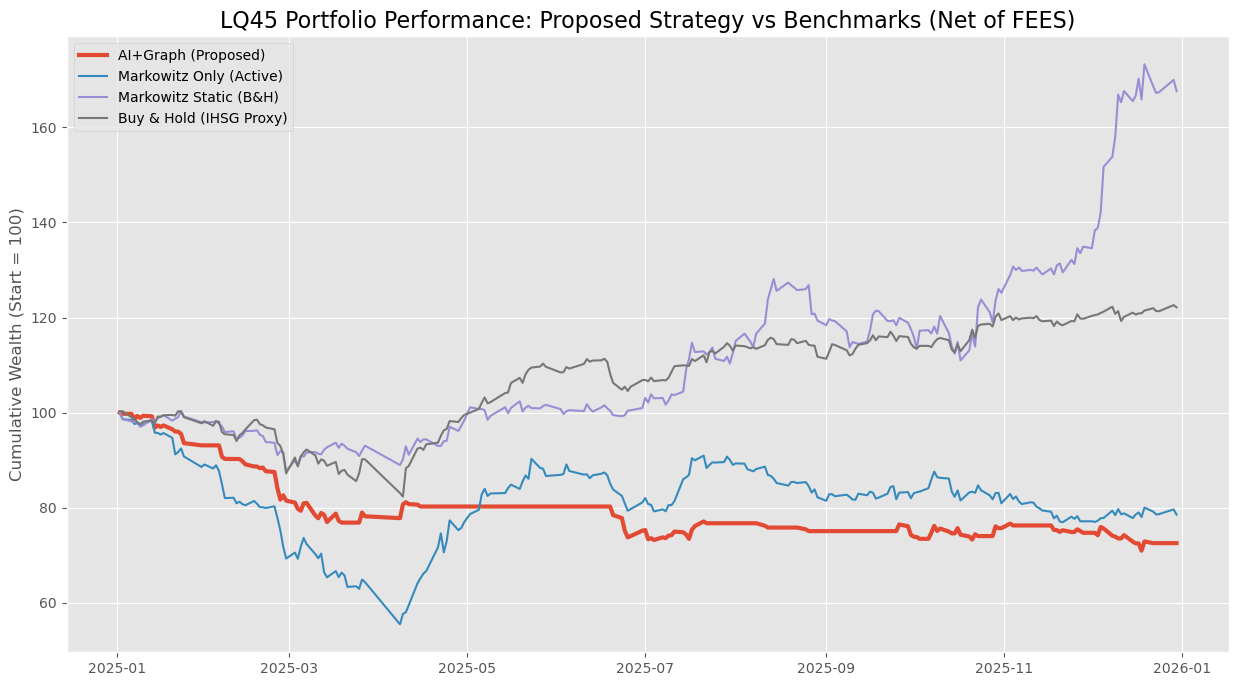

,Strategy,Return %,Sharpe,MaxDrawdown
0,AI+Graph (Proposed),-27.44%,-2.17,-29.03%
1,Markowitz Only (Active),-21.45%,-0.63,-44.50%
2,Markowitz Static (B&H),67.60%,2.19,-13.38%
3,Buy & Hold (IHSG Proxy),22.13%,1.14,-17.90%


In [5]:
# --- 5. Visualization & Metrics ---
plt.figure(figsize=(15, 8))
for label, df in results.items():
    lw = 3 if 'Proposed' in label else 1.5
    plt.plot(df.index, df['Portfolio_Value'], label=label, linewidth=lw)

plt.title("LQ45 Portfolio Performance: Proposed Strategy vs Benchmarks (Net of FEES)", fontsize=16)
plt.ylabel("Cumulative Wealth (Start = 100)")
plt.legend()
plt.grid(True)
plt.show()

# Summary Table
summary = []
for label, df in results.items():
    rets = df['Portfolio_Value'].pct_change().dropna()
    tot = (df['Portfolio_Value'].iloc[-1] / 100) - 1
    sh = (rets.mean() * 252) / (rets.std() * np.sqrt(252))
    mdd = (df['Portfolio_Value'] / df['Portfolio_Value'].cummax() - 1).min()
    summary.append({'Strategy': label, 'Return %': f"{tot:.2%}", 'Sharpe': round(sh, 2), 'MaxDrawdown': f"{mdd:.2%}"})

display(pd.DataFrame(summary))